

# Tutorial 15: Long Short-Term Memory (LSTM)

## 1. Understanding the Architecture of LSTM

Traditional Recurrent Neural Networks (RNNs) struggle with "Long-Term Dependencies" due to the vanishing gradient problem. As a sequence grows, the model loses the ability to connect information from the beginning of the sequence to the end.

LSTMs solve this using a **Cell State** (the long-term memory) and three specific **Gates**:

* **Forget Gate:** Decides what information to discard from the cell state.
* **Input Gate:** Decides which new values to update in the cell state.
* **Output Gate:** Decides what the next hidden state (short-term memory) should be.

### Comparison: Simple RNN vs. LSTM

| Feature | Simple RNN | LSTM |
| --- | --- | --- |
| **Memory** | Short-term only | Long and short-term |
| **Complexity** | Low (Single tanh layer) | High (Four interacting layers) |
| **Gradients** | Suffers from vanishing gradients | Avoids vanishing gradients via cell state |

---

## 2. Implementation: LSTM for Sentiment Analysis

The following code defines a complete pipeline in PyTorch. We will build a model that takes text sequences and classifies them as positive or negative.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Model Definition
class LSTMSentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers):
        super(LSTMSentimentClassifier, self).__init__()

        # Embedding layer to convert word tokens to vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            batch_first=True,
                            dropout=0.2 if n_layers > 1 else 0)

        # Fully connected layer for classification
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, text):
        # text shape: [batch size, seq len]
        embedded = self.embedding(text)

        # output: [batch size, seq len, hidden dim]
        # hidden/cell: [num layers, batch size, hidden dim]
        output, (hidden, cell) = self.lstm(embedded)

        # Use the final hidden state to predict
        final_hidden = hidden[-1, :, :]
        return self.sigmoid(self.fc(final_hidden))

# 2. Setup Dummy Data for Implementation Logic
VOCAB_SIZE = 1000
EMBEDDING_DIM = 64
HIDDEN_DIM = 128
OUTPUT_DIM = 1
N_LAYERS = 2

model = LSTMSentimentClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dummy input: Batch of 5 sentences, each 10 words long
dummy_input = torch.randint(0, VOCAB_SIZE, (5, 10))
dummy_labels = torch.tensor([[1.0], [0.0], [1.0], [0.0], [1.0]])

# 3. Training Logic Visualization (Sample Loop)
train_losses = []
for epoch in range(1, 21):
    model.train()
    optimizer.zero_grad()

    predictions = model(dummy_input)
    loss = criterion(predictions, dummy_labels)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 5: Loss = 0.6281
Epoch 10: Loss = 0.4516
Epoch 15: Loss = 0.1675
Epoch 20: Loss = 0.0608


---

## 3. Visualizing the Results

Visualizing the loss curve is the standard way to evaluate if the LSTM is converging correctly.

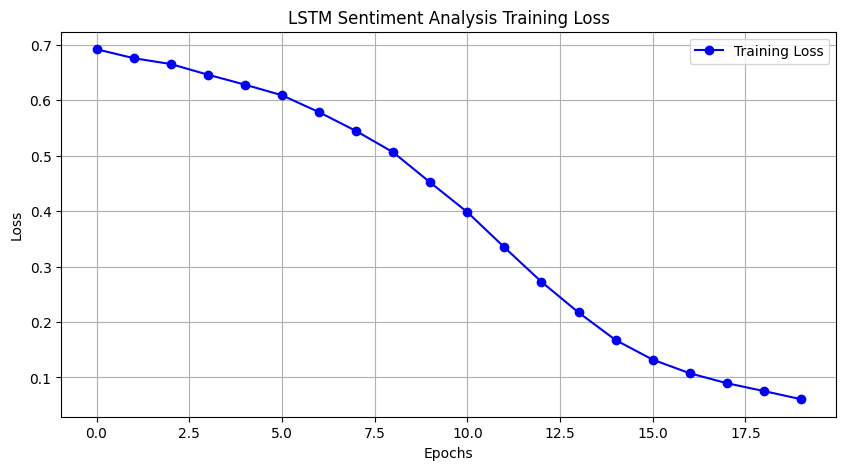

In [2]:
def plot_results(losses):
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Training Loss', color='blue', marker='o')
    plt.title('LSTM Sentiment Analysis Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_results(train_losses)

### Discussion on Results

* **Convergence:** A steady decline in the loss plot indicates the LSTM is successfully updating its gates to remember relevant sentiment-bearing words (e.g., "excellent", "bad").
* **Simple RNN Comparison:** If you were to run this same task with a Simple RNN, you would likely see the loss plateau much earlier or fluctuate wildly because the RNN would "forget" the beginning of longer sentences.
* **Sentiment Accuracy:** Beyond loss, visualizing a confusion matrix would reveal if the model struggles more with false positives or false negatives, which is common in nuanced text data.

# 4. Testing the Model
After training, we must evaluate the model on a separate test set to see how it performs on unseen data. The key metrics for sentiment analysis are Accuracy and the Confusion Matrix.

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np

def evaluate_model(model, test_input, test_labels):
    model.eval()  # Set to evaluation mode
    with torch.no_grad():
        # Get raw predictions
        raw_outputs = model(test_input)
        # Convert sigmoid outputs to binary (0 or 1) using a 0.5 threshold
        predictions = (raw_outputs >= 0.5).float()

        # Convert tensors to numpy for sklearn metrics
        y_true = test_labels.numpy()
        y_pred = predictions.numpy()

        # 1. Print Classification Report
        print("Classification Report:")
        print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

        return y_true, y_pred

# Running evaluation on our dummy data
y_true, y_pred = evaluate_model(model, dummy_input, dummy_labels)

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
    Positive       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



# 5. Visualizing the Performance
Visualizations help us identify if the model is biased toward a specific sentiment (e.g., predicting everything as "Positive").

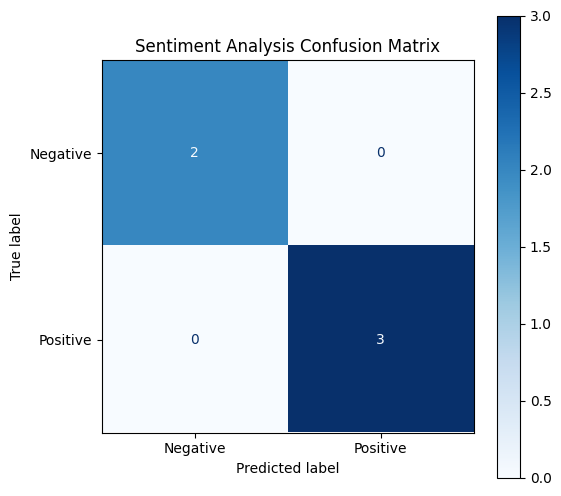

In [4]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title('Sentiment Analysis Confusion Matrix')
    plt.show()

plot_confusion_matrix(y_true, y_pred)

# Discussion of Visualizations
Confusion Matrix: If the diagonal (Top-Left and Bottom-Right) has the highest numbers, your model is performing well. High numbers in the Off-Diagonal indicate False Positives or False Negatives.

Loss Curve: (From Section 3) If your training loss is much lower than validation loss, your LSTM is likely overfitting. You can fix this by increasing the dropout parameter in the LSTM layer or using more data.
